# Visualisation des modèles

*Petit paragraphe de présentaion ?*

In [16]:
import numpy as np
import matplotlib.pyplot as plt

import fonctions_communes as fct
import fonctions_complet as com
import fonctions_separe as sep
import fonctions_affichage as aff

import fonctions_communes_claude as fct_claude

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
#import matplotlib.pyplot as plt
#from scipy.optimize import linprog
#import pandas as pd
#import pulp
#import networkx as nx
#from ipywidgets import interact, IntSlider

## 1. Choix des paramètres de simulation et chargement des données

### 1.1. Choix des paramètres de simulation

In [18]:
phs_capacity = 30*180 # modifié en faisant 30*
phs_power = 5*9.3 # modifié en faisant 5*
phs_eff=0.75 
ptg_capacity = 125000
ptg_init_rate = 0.75 # taux initial de remplissage des stocks (entre 0 et 1)
ptg_power_in = 60*7.66 # modifié en faisant 60*
ptg_power_out = 2*32.93 # modifié en faisant 2*
ptg_eff = 0.4

# Seulement pour le SEPARE :
penalisation = 1e10
flux_eff = 0.9

### 1.2. Chargement des données pour les années 2019 à 2023

Chargement des données pour 1 pays du code jouet et définition des capacités requises :

In [19]:
demand_N, solar_cap_N, wind_cap_N, solar_N, wind_N = fct_claude.charge_data_multi()
print(demand_N.shape)
solar_N = solar_N * 2


Données prêtes : Matrice Solaire (8760, 5), Matrice Éolienne (8760, 5)
(8760, 5)


Chargement des capacité d'échange maximales :

In [20]:
N = demand_N.shape[1]
qmax5pays = fct_claude.capa_max_echanges()
qmax = 5*qmax5pays[:N,:N]
print("Matrice des capacités d'échanges max :", qmax, sep='\n')

Matrice des capacités d'échanges max :
[[ 0.   2.   1.   9.5  6.5]
 [17.5  0.   4.   0.   2. ]
 [ 9.   3.5  0.   6.   0. ]
 [ 9.   0.   5.   0.   0. ]
 [ 8.   2.5  0.   0.   0. ]]


### 1.3 Choix des paramètres d'affichage

## 2. Simulation des modèles "Complet" et "Séparé" sur 1 an

### 2.1. Complet

In [21]:
result_complet = com.optimize_5years(
    wind_profile=wind_N,
    solar_profile=solar_N,
    demand=demand_N,
    wind_cap=wind_cap_N,
    solar_cap=solar_cap_N,
    qmax_matrix=qmax,
    phs_capacity=phs_capacity, 
    phs_power=phs_power, 
    phs_eff=phs_eff,
    ptg_capacity=ptg_capacity,
    ptg_power_in=ptg_power_in,
    ptg_power_out=ptg_power_out,
    ptg_eff=ptg_eff
)

Interprétation graphique :

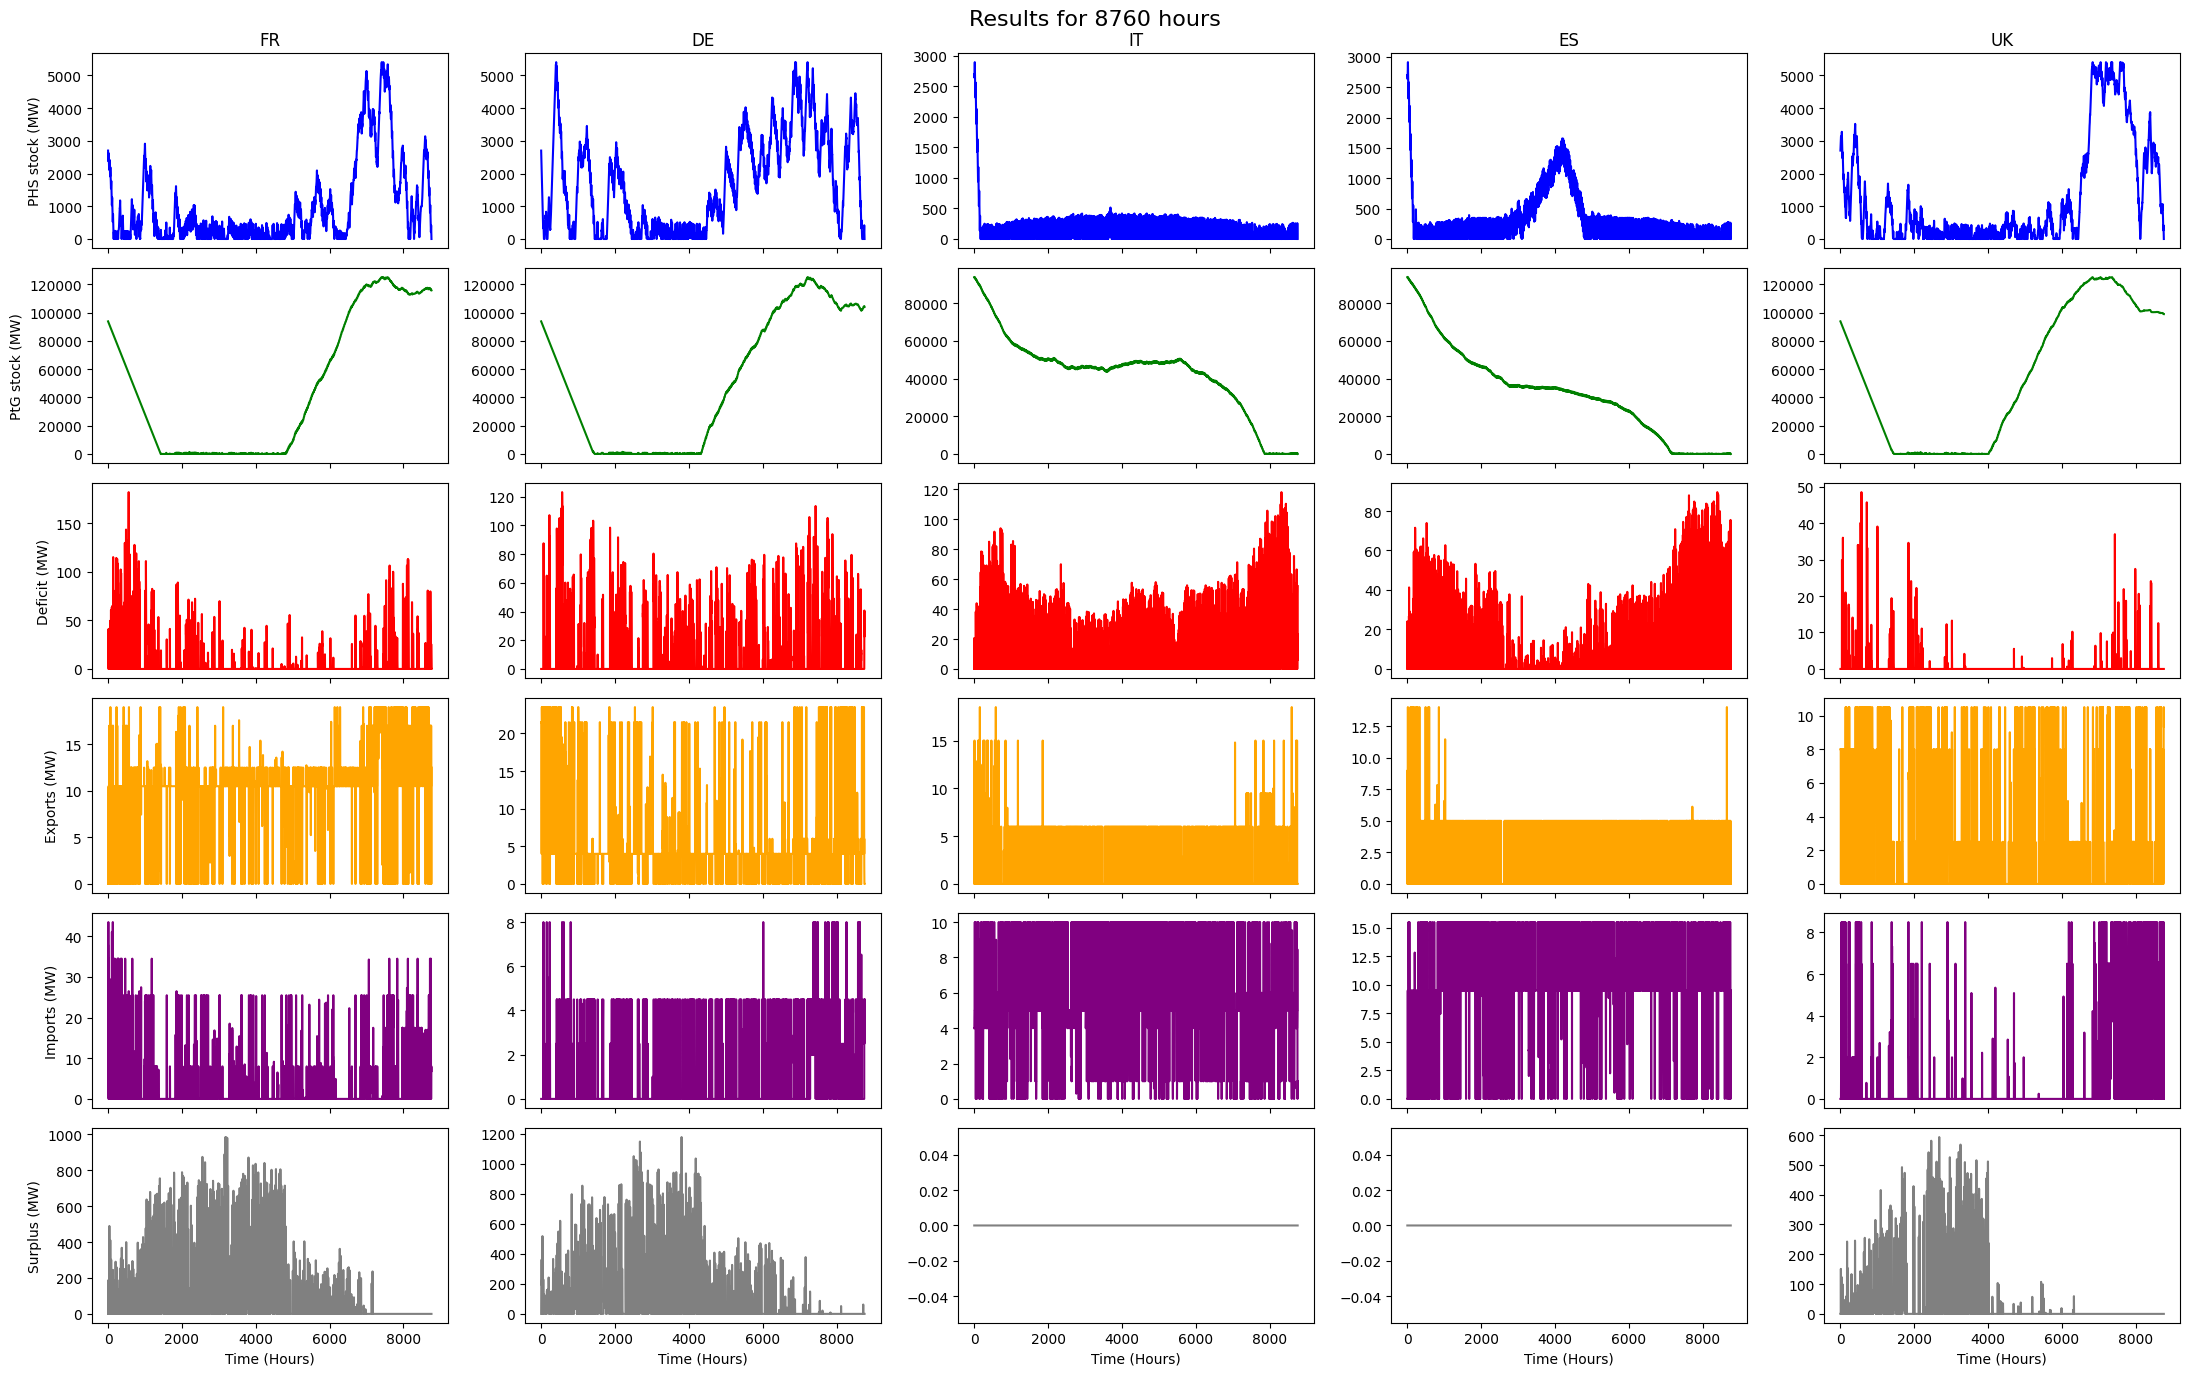

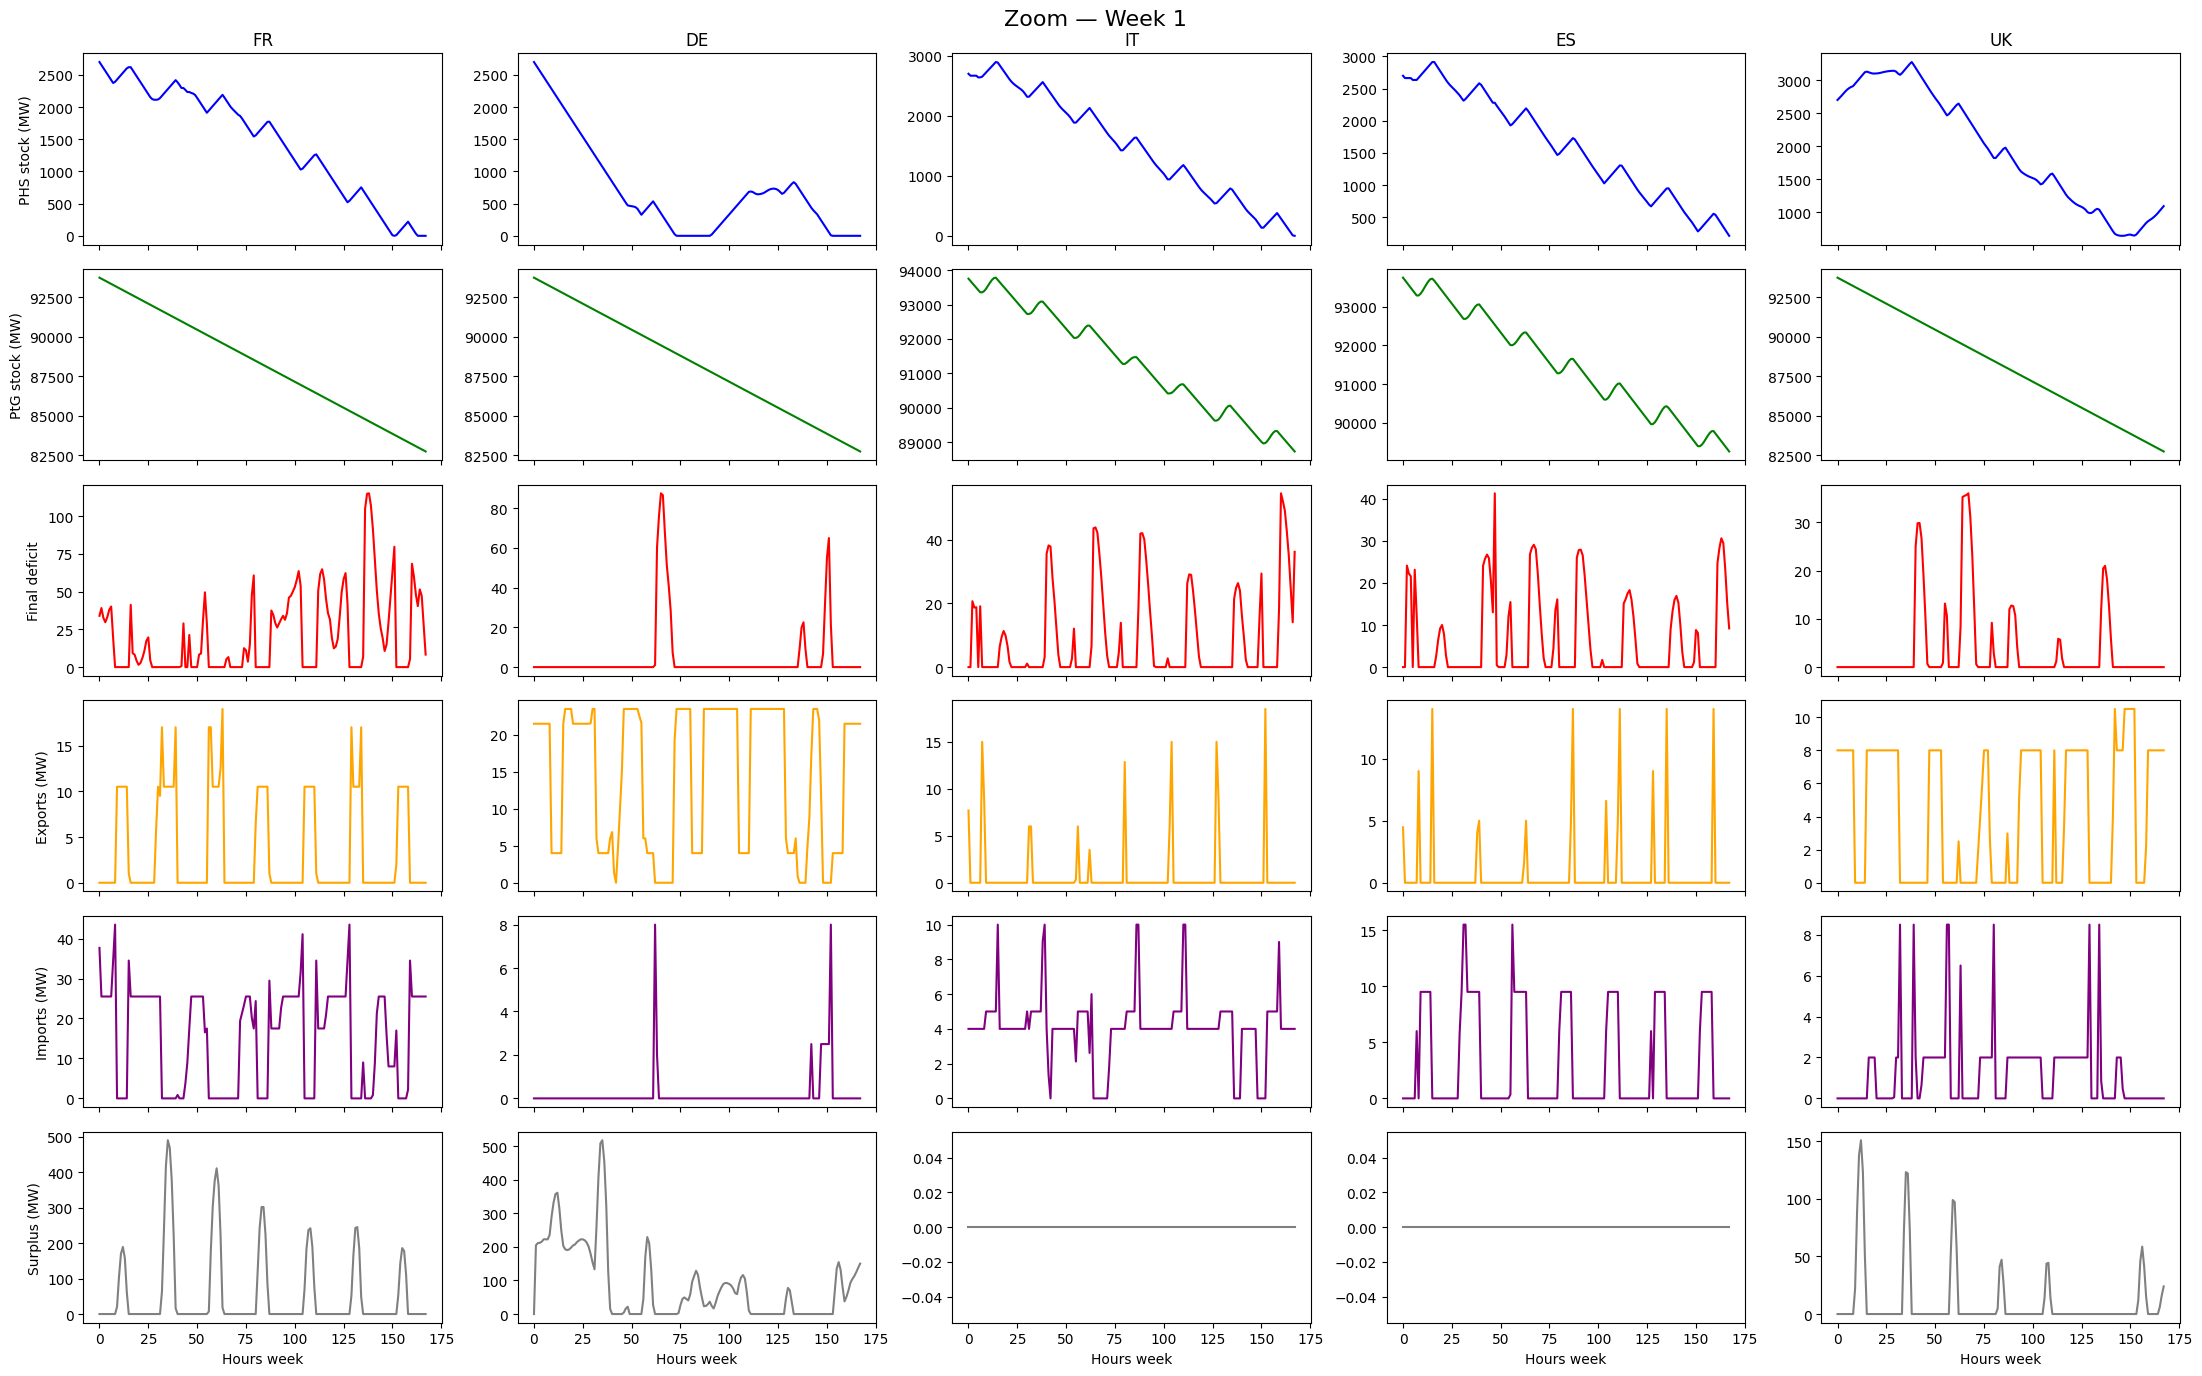

In [22]:
aff.plot_graphs_multi(result_complet, semaine=1)

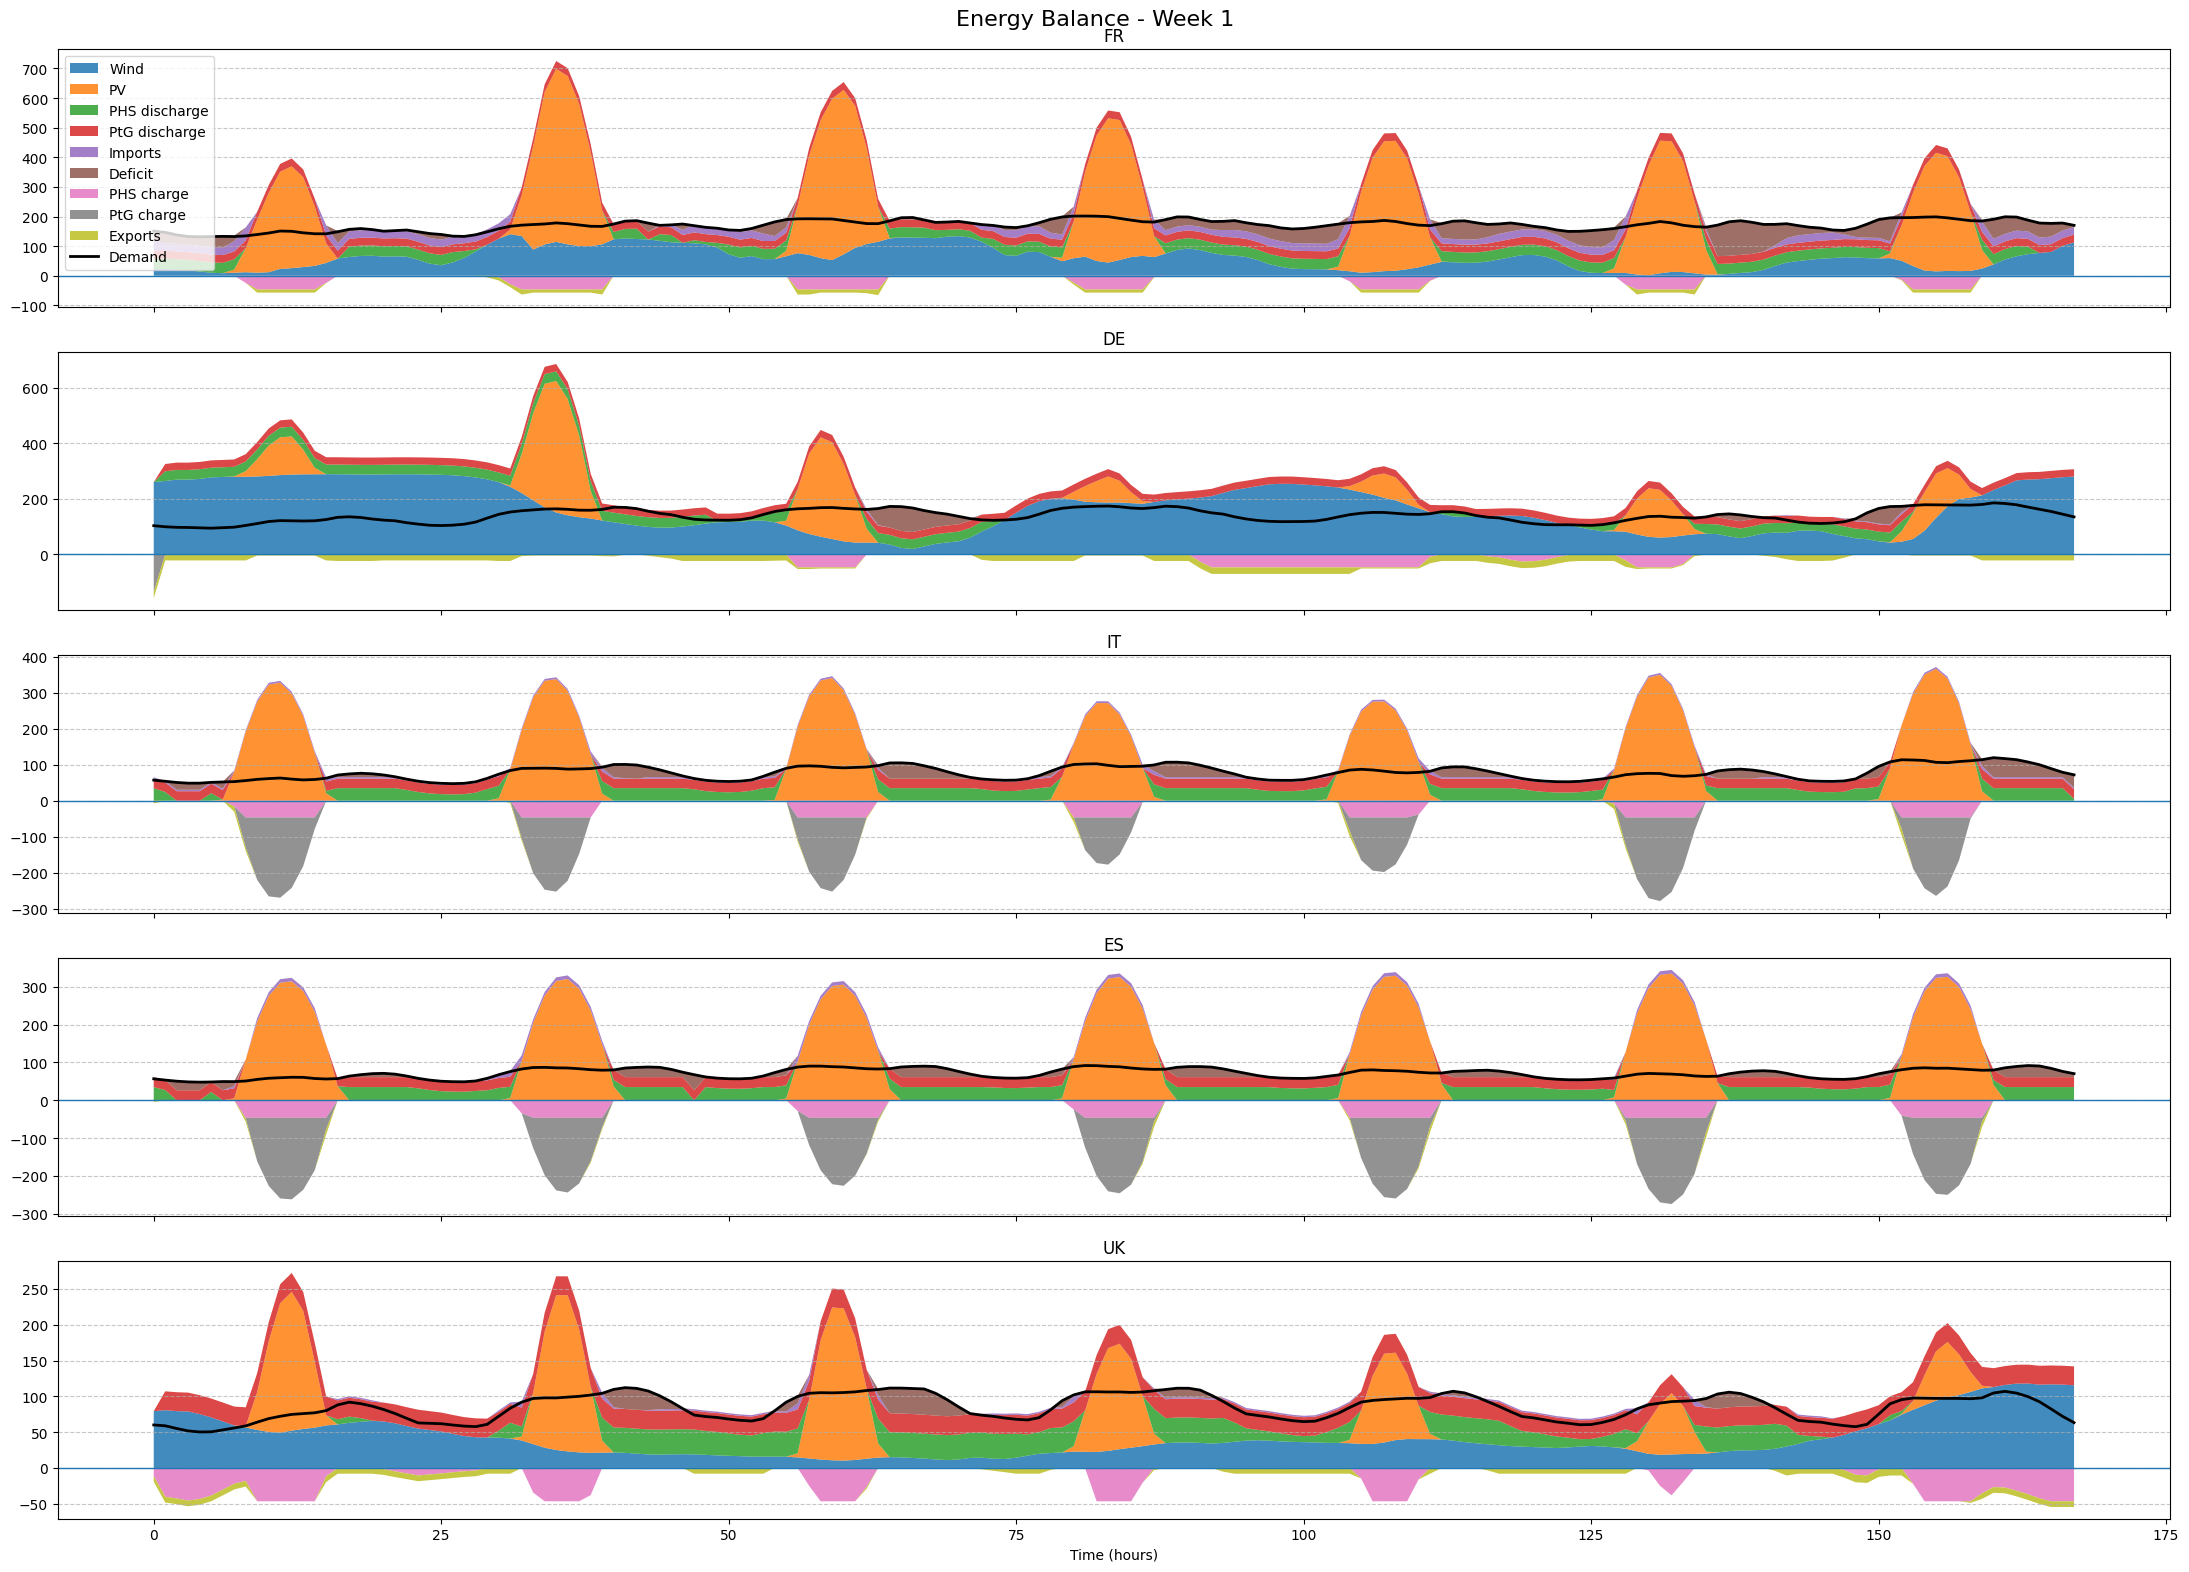

In [23]:
aff.plot_global_graph_multi(result_complet, demand_N=demand_N, wind_N=wind_N, wind_cap_N=wind_cap_N, solar_N=solar_N, solar_cap_N=solar_cap_N, ptg_eff=ptg_eff, phs_eff=phs_eff, semaine=1)

### 2.2 Séparé

In [24]:
# Utilisation de la V3

result_separe = sep.optimize3(
    wind_profile=wind_N,
    solar_profile=solar_N,
    demand=demand_N,
    wind_cap=wind_cap_N,
    solar_cap=solar_cap_N,
    qmax_matrix=qmax,
    phs_capacity=phs_capacity, 
    phs_power=phs_power, 
    phs_eff=phs_eff,  
    ptg_capacity=ptg_capacity,
    ptg_init_rate=ptg_init_rate,
    ptg_power_in=ptg_power_in,
    ptg_power_out=ptg_power_out,
    ptg_eff=ptg_eff,
    penalisation=penalisation,
    flux_eff=flux_eff
)


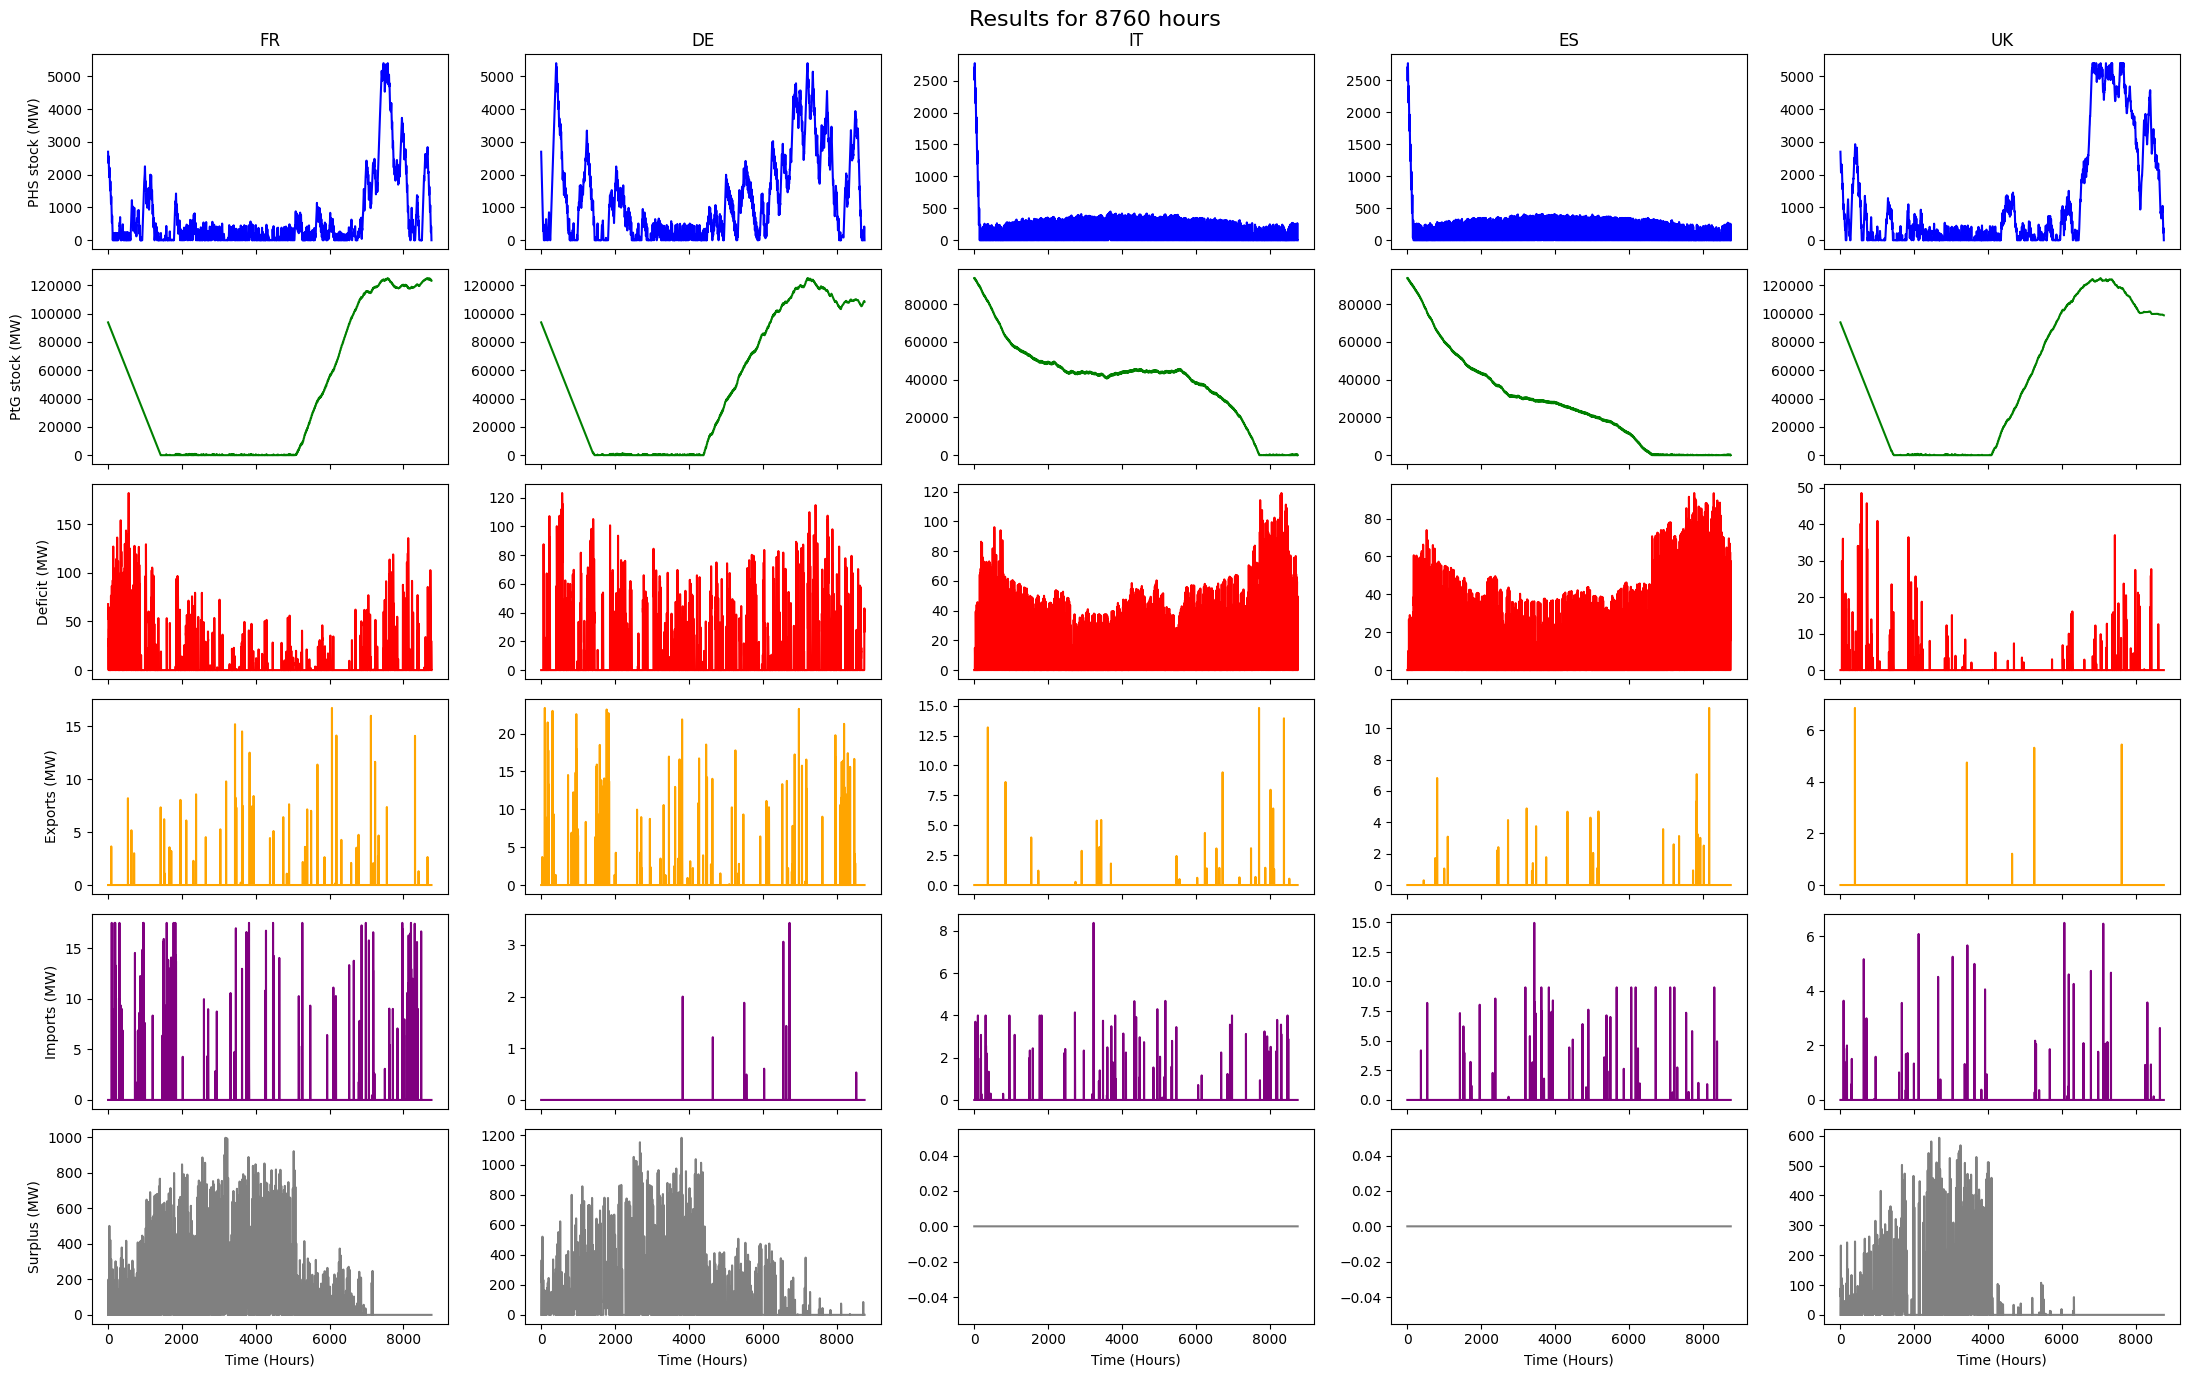

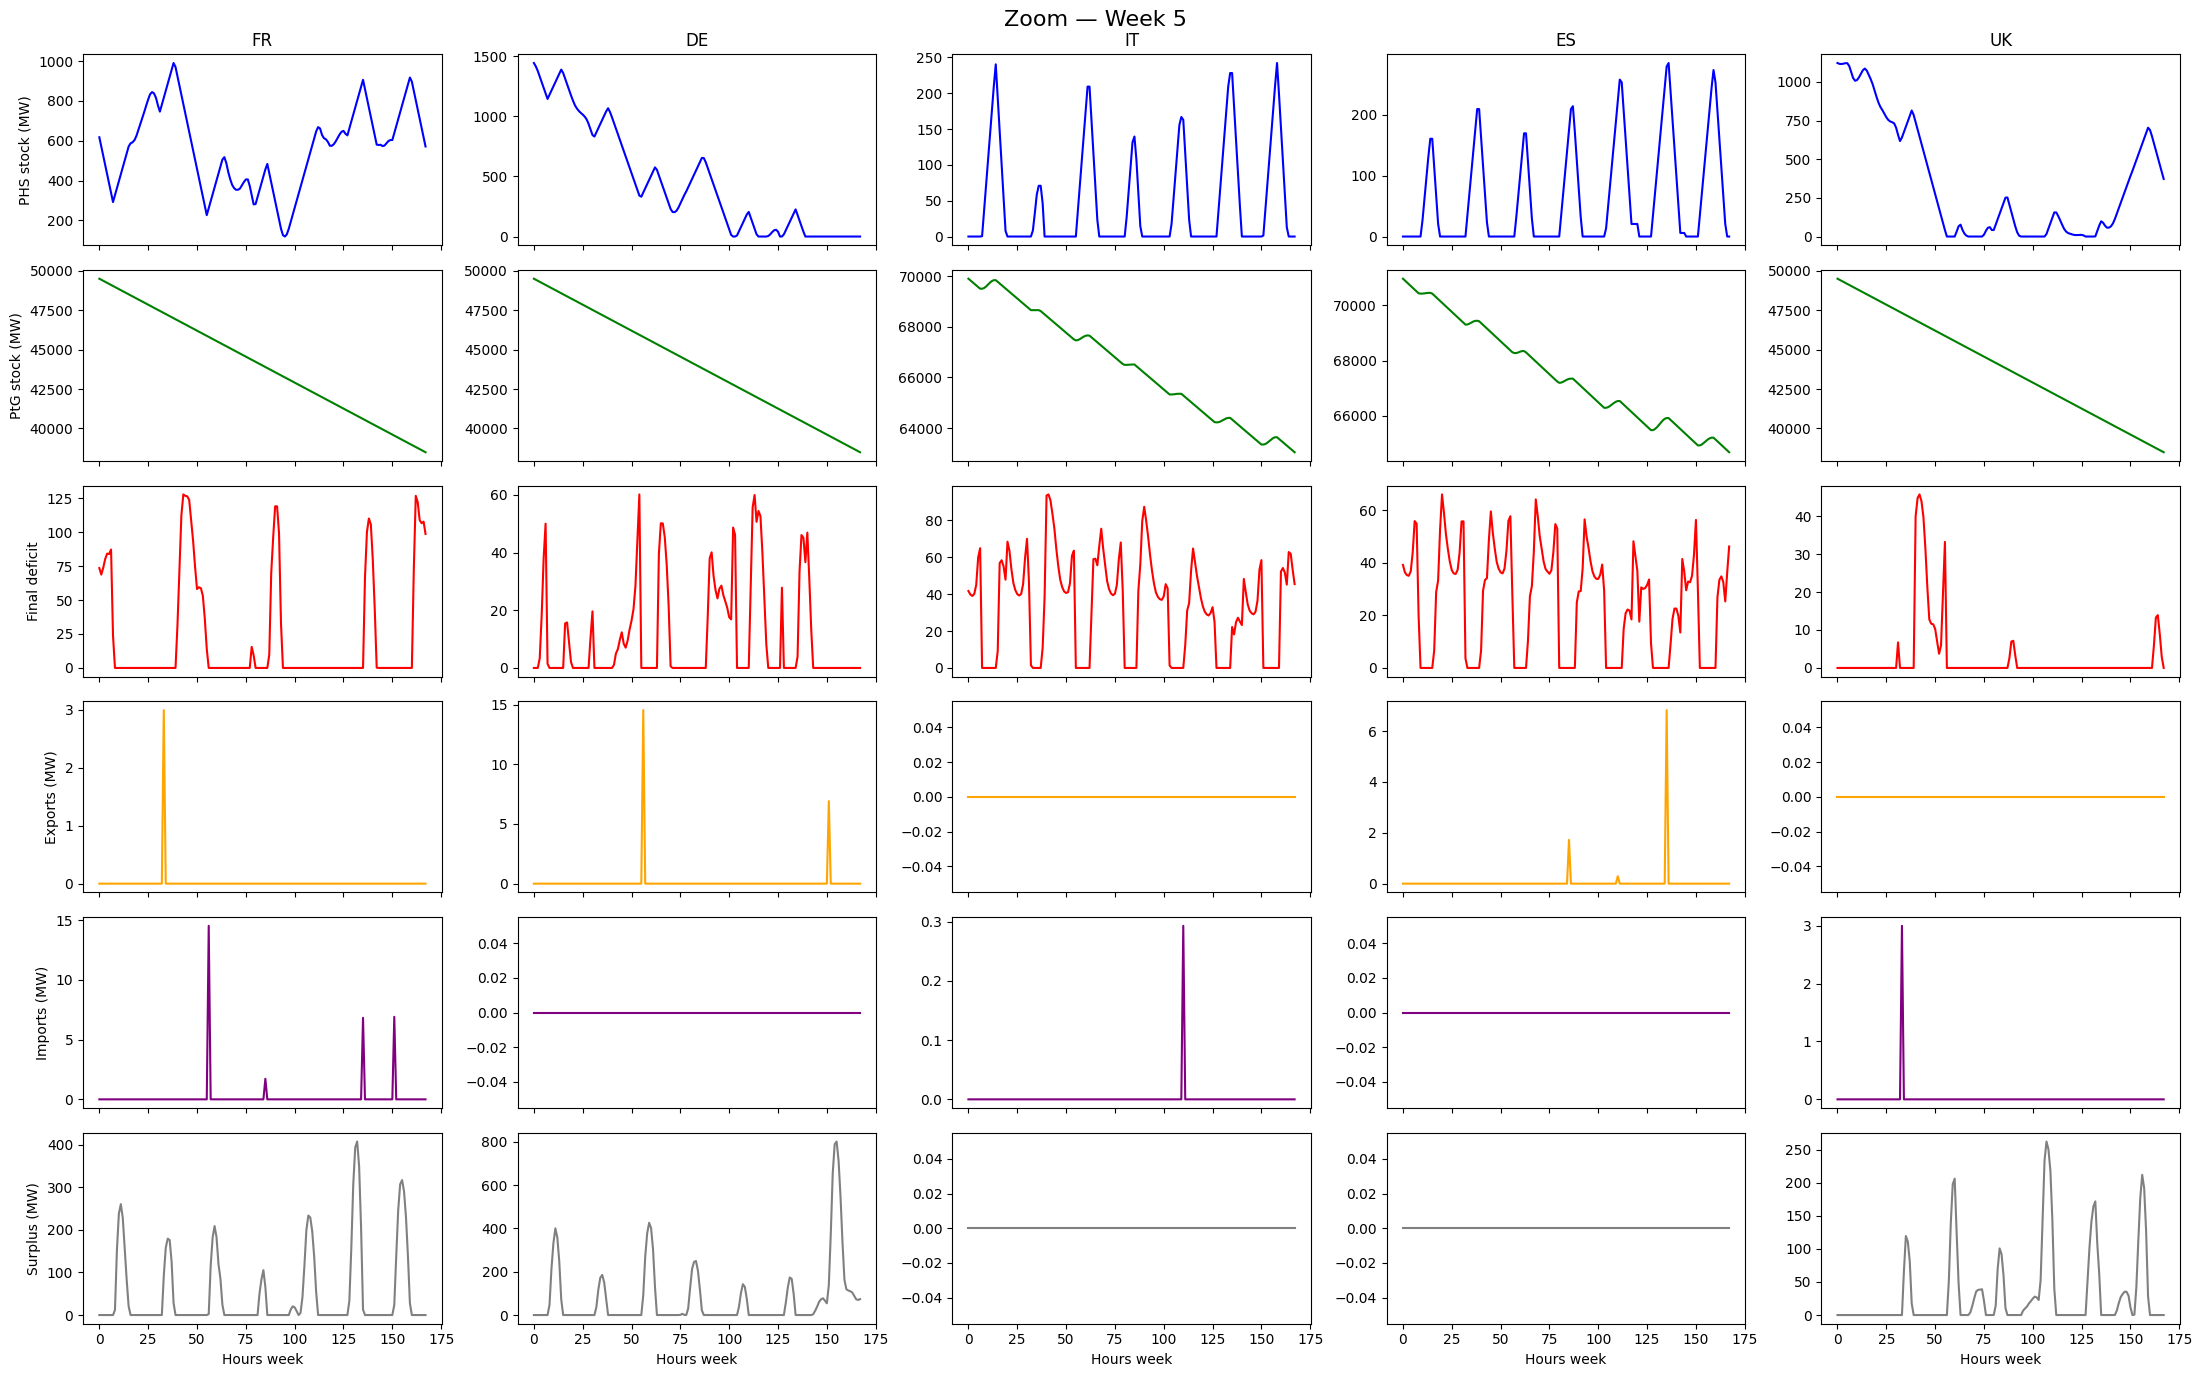

In [25]:
aff.plot_graphs_multi(result_separe)

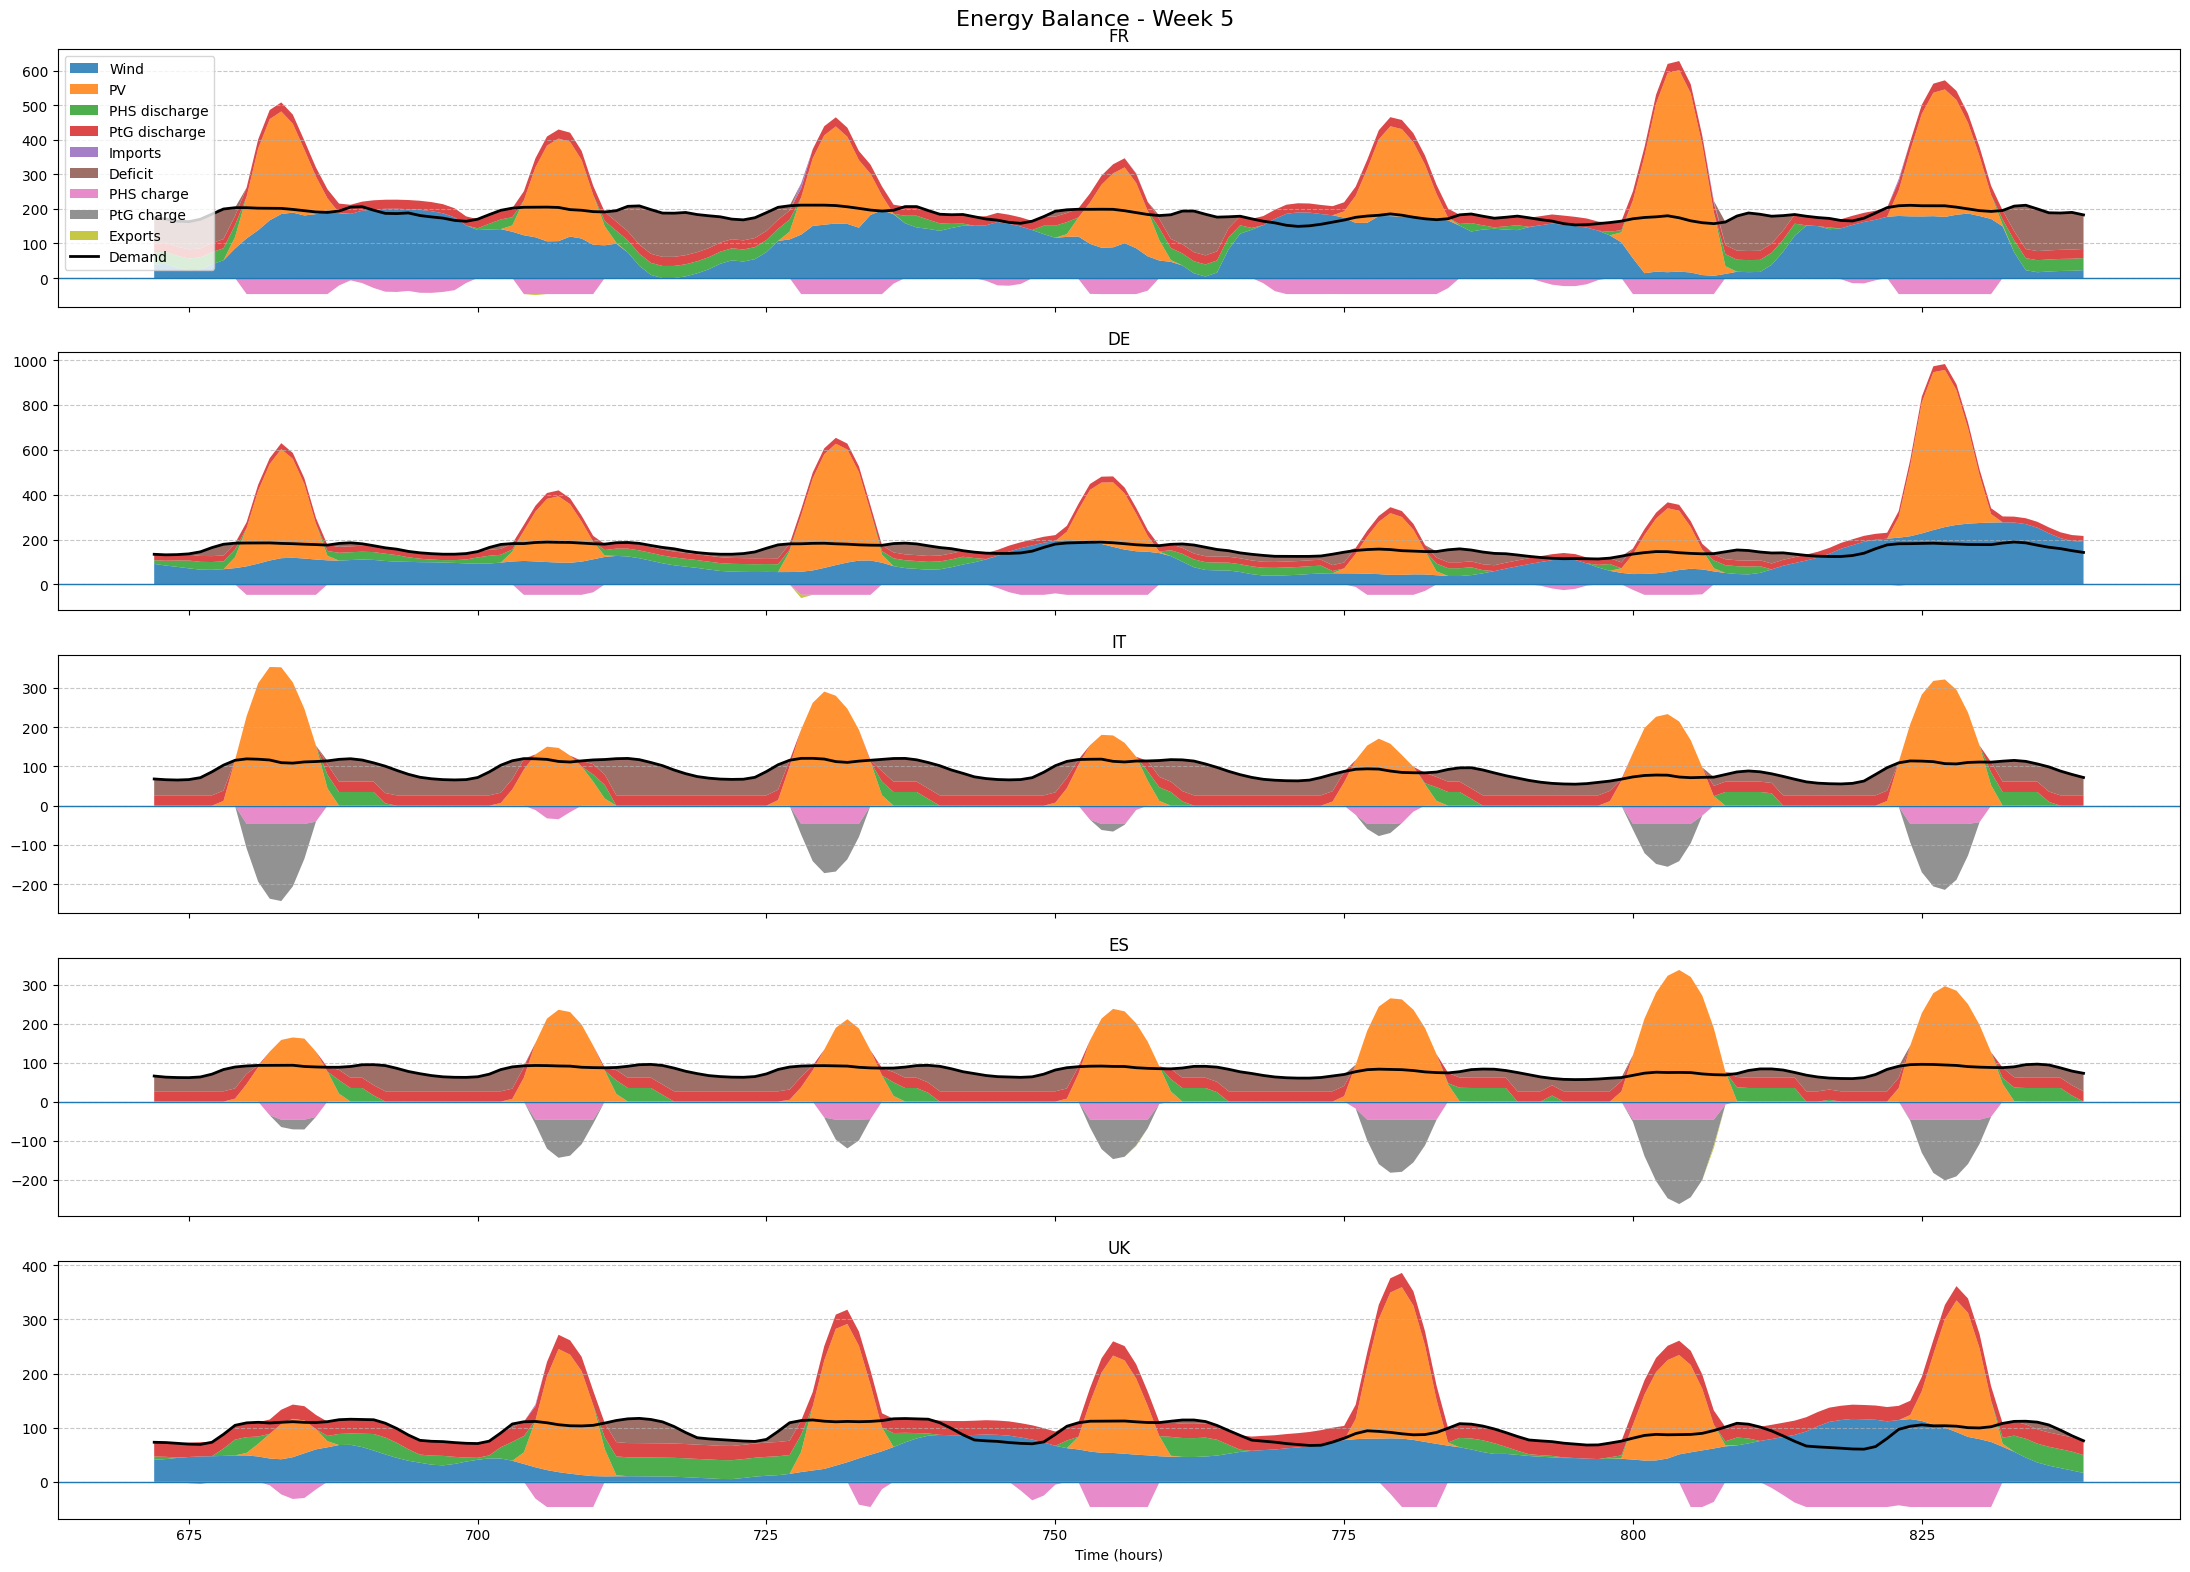

In [26]:
aff.plot_global_graph_multi(result_separe, demand_N=demand_N, wind_N=wind_N, wind_cap_N=wind_cap_N, solar_N=solar_N, solar_cap_N=solar_cap_N, ptg_eff=ptg_eff, phs_eff=phs_eff, semaine=5)

### 2.3 Différence entre les deux modèles de la quantité d'électricité non servie

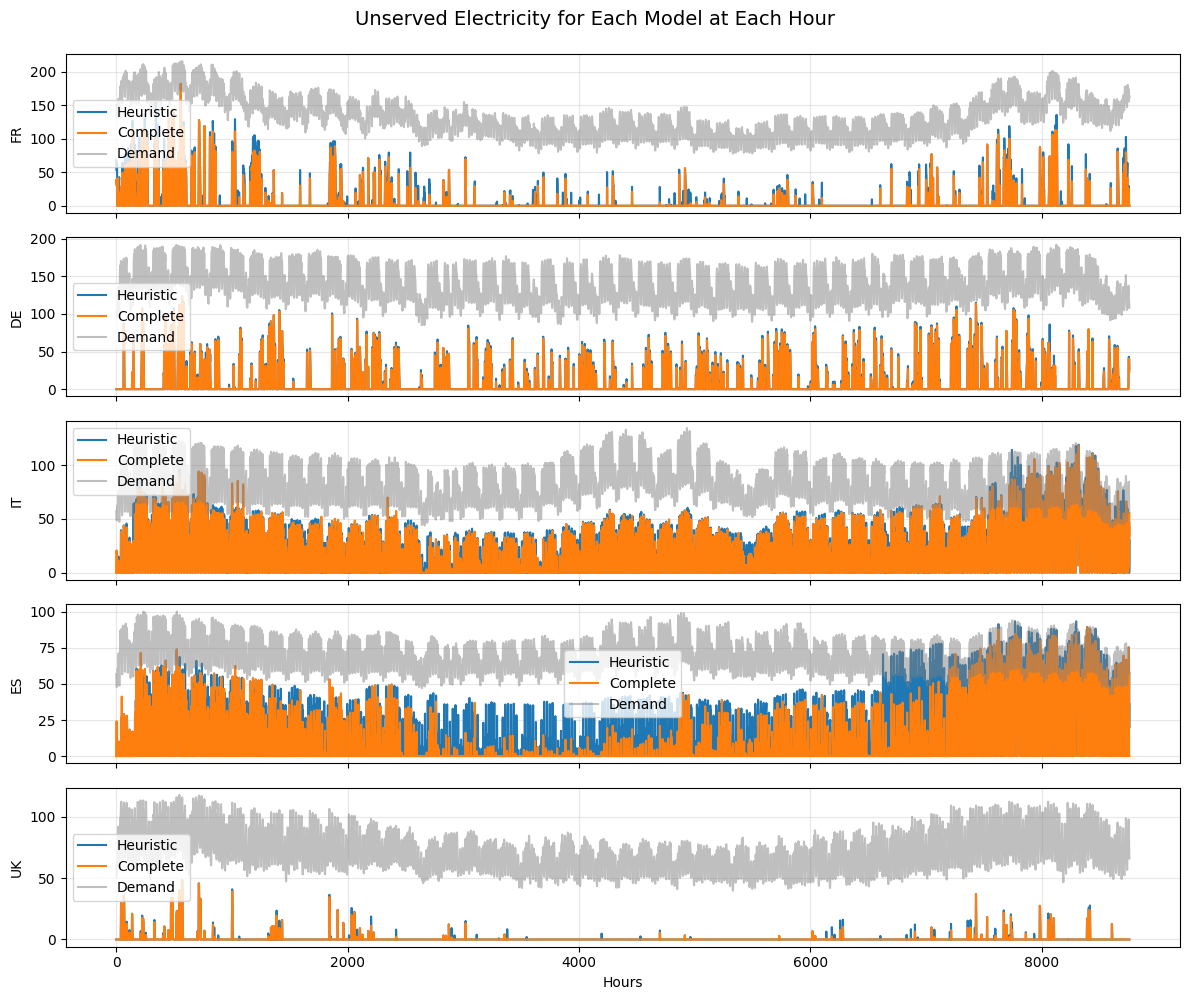

In [27]:
import pandas as pd

deficit_separe = (result_separe['deficit_final']) # électricité non servie à chaque heure dans le modèle séparé
deficit_complet = (result_complet['deficit_final']) # électricité non servie à chaque heure dans le modèle complet

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
countries = pd.read_csv("./data_exchange/areas_5countries.csv", header=None).squeeze("columns")

for i in range(5):
    axes[i].plot(deficit_separe[:, i], label='Heuristic')
    axes[i].plot(deficit_complet[:, i], label='Complete')
    axes[i].plot(demand_N[:, i], label='Demand', c='gray', alpha=0.5)
    axes[i].set_ylabel(f'{countries[i]}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Hours')

fig.suptitle('Unserved Electricity for Each Model at Each Hour', fontsize=14, y=0.995) # Put the units

plt.tight_layout()
plt.show()

In [28]:
difference = deficit_separe - deficit_complet

indices_sep = np.where(difference < 0)[0] # Les heures auxquelles Séparé renvoit un déficit plus petit que complet
indices_comp = np.where(difference > 0)[0]
print("Total number of hours : ", len(difference))
print("-----------------------------")
print("Number of hours where the result for deficit is better with the Heuristic algorithm : ", len(indices_sep))
print("Number of hours where the result for deficit is better with the Complete algorithm : ", len(indices_comp))
print("Number of equal values :", len(difference)- len(indices_sep) -len(indices_comp))

#print("Indices:", indices_sep)
#print("Valeurs:", difference[indices_sep])

Total number of hours :  8760
-----------------------------
Number of hours where the result for deficit is better with the Heuristic algorithm :  514
Number of hours where the result for deficit is better with the Complete algorithm :  10613
Number of equal values : -2367


In [29]:
# Déficit cumulé là où Séparé donne un résultat moins bon
cumul_comp = np.sum(deficit_complet[indices_comp], axis=0) # vecteur de taille 5 : une valeur pour chaque pays
cumul_sep = np.sum(deficit_separe[indices_comp], axis=0)
cumul_dem =np.sum(demand_N[indices_comp], axis=0)
print("Cumulative demand by country :                       ", np.array2string(cumul_dem, precision=1, suppress_small=True))
print("Cumulative deficit by country with the Complete model : ", np.array2string(cumul_comp, precision=1, suppress_small=True))
print("Cumulative deficit by country with the Heuristic model :  ", np.array2string(cumul_sep, precision=1, suppress_small=True))
print("-----------------------------")

# Ratios (en pourcent)
ratio_comp = 100*(cumul_comp/cumul_dem)
ratio_sep = 100*(cumul_sep/cumul_dem)
print("Part of cumulative demand not served (%)")
print("-> With the Complete model : ",  np.array2string(ratio_comp, precision=0, suppress_small=True))
print("-> With the Heuristic model :  ",  np.array2string(ratio_sep, precision=0, suppress_small=True))

Cumulative demand by country :                        [1403820.7 1420958.6  832647.3  723967.4  755305.6]
Cumulative deficit by country with the Complete model :  [ 82682.7 161381.9 325724.2 197817.8   5279.7]
Cumulative deficit by country with the Heuristic model :   [119598.8 178769.  369745.5 294715.6   7714.4]
-----------------------------
Part of cumulative demand not served (%)
-> With the Complete model :  [ 6. 11. 39. 27.  1.]
-> With the Heuristic model :   [ 9. 13. 44. 41.  1.]


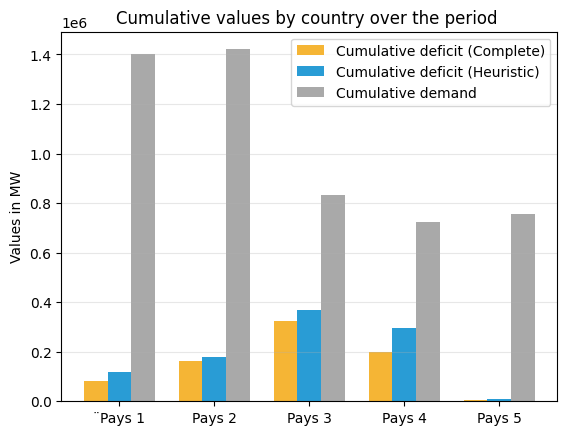

In [30]:
# Même chose mais visuellement

x = np.arange(5)  # [0, 1, 2, 3, 4]
largeur = 0.25

plt.bar(x - largeur, cumul_comp, largeur, label='Cumulative deficit (Complete)', color="#F5B535")
plt.bar(x, cumul_sep, largeur, label='Cumulative deficit (Heuristic)', color='#299CD5')
plt.bar(x + largeur, cumul_dem, largeur, label='Cumulative demand', color="#A9A9A9")

plt.ylabel('Values in MW')
plt.title('Cumulative values by country over the period ')
plt.xticks(x, ['¨Pays 1', 'Pays 2', 'Pays 3', 'Pays 4', 'Pays 5'])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()